# Analysis of Beamspot

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
from utils import load_root_file, load_hepmc_event
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df

## Load PDA output data

In [2]:
acts_base_path = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/pda_testing16")
hits_df = load_root_file(acts_base_path / "simhits.root")
measurements_df = load_root_file(acts_base_path / "measurements.root")
# calo_df = load_root_file(acts_base_path / "calohits.root")
particles_df = load_root_file(acts_base_path / "particles.root")

# hits_df = hits_df[hits_df["event_id"] == 0]
# calo_df = calo_df[calo_df["event_id"] == 0]

## Primary Vertex Study

In [43]:
primaries = particles_df[particles_df.generation == 1]

In [44]:
primaries

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_primary,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome
entry,,,,,,,,,,,,,,,,,,,,,
45,0,4504699155841028,-2,0,-0.000497,0.011004,39.516254,2022.685791,-0.687327,1.917896,...,1,1,1,1,4,41.069878,0.0,0.0,0,0
46,0,4504699155841029,21,0,-0.000497,0.011004,39.516254,2022.685791,-1.376948,2.469618,...,1,1,1,1,5,46.143414,0.0,0.0,0,0
47,0,4504699155841031,21,0,-0.000497,0.011004,39.516254,2022.685791,-0.166541,-1.330175,...,1,1,1,1,7,1.947461,0.0,0.0,0,0
48,0,4504699155841032,21,0,-0.000497,0.011004,39.516254,2022.685791,0.111218,-0.140121,...,1,1,1,1,8,0.570567,0.0,0.0,0,0
49,0,4504699155841035,-1,0,-0.000497,0.011004,39.516254,2022.685791,0.011486,0.544911,...,1,1,1,1,11,12.354735,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154619,2,8943432127022430,1,0,-0.015307,0.016599,36.256157,-258.000763,0.411278,-0.848392,...,1,4038,271,1,1374,8.318888,0.0,0.0,0,0
154666,2,8946731567875657,21,0,0.009879,-0.020028,44.735779,-2112.457764,-0.189842,-0.028359,...,1,4041,325,1,1609,1.463205,0.0,0.0,0,0
154890,2,8964322361410757,21,0,-0.017934,0.006722,-52.920105,-305.537720,2.997309,-0.247896,...,1,4057,242,1,1221,22.577623,0.0,0.0,0,0


<Axes: ylabel='Count'>

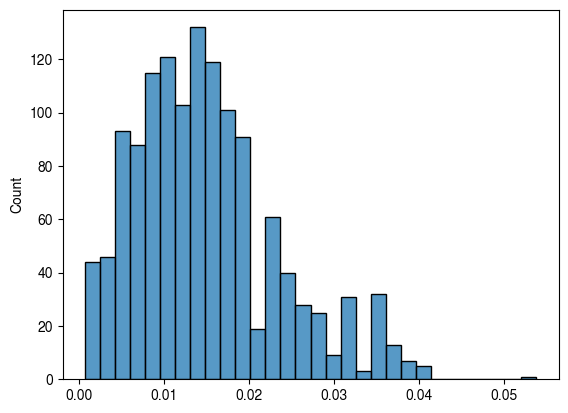

In [45]:
odd_d0 = np.sqrt(primaries.vx**2 + primaries.vy**2)

sns.histplot(odd_d0, bins=30)

<Axes: xlabel='vz', ylabel='Count'>

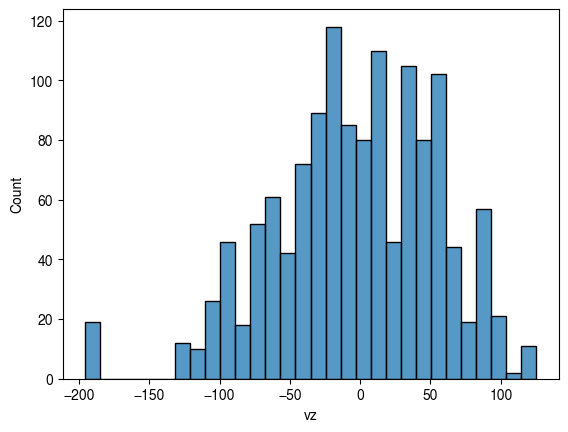

In [46]:
odd_z0 = primaries.vz
sns.histplot(odd_z0, bins=30)


## ITk Data

In [47]:
import athena_root_utils, athena_utils, athena_datatypes

In [48]:
root_dir = "/global/cfs/cdirs/m3443/data/GNN4ITK/CHEP2024_data/root_files/user.avallier.mc21_14TeV.601229.PhPy8EG_A14_ttbar_hdamp258p75_SingleLep.DumpGNN4ITk_v5.e8481_s4149_r15238_EXT0"
root_file = root_dir + "/user.avallier.38040858.EXT0._000168.Dump_GNN4Itk.root"

In [49]:
# Read itk root file
itk_tree = uproot.open(root_file)['GNN4ITk;1']

In [50]:
part_branches = itk_tree.arrays(
                athena_root_utils.particle_branch_names,
                entry_start=4,
                entry_stop=5,
                library="np",
            )
part_branches.keys()

particles = athena_root_utils.read_particles(part_branches)
particles = athena_utils.convert_barcodes(particles)
particles.pt /= 1000 # Convert to GeV
particles.particle_id = particles.particle_id.astype(str)
particles["is_primary"] = (particles.barcode.astype(int) < 200000)

In [51]:
particles

,particle_id,subevent,barcode,px,py,pz,pt,eta,vx,vy,...,radius,status,charge,pdgId,pass,vProdNIn,vProdNOut,vProdStatus,vProdBarcode,is_primary
0,11500000003,1150,3,0.000000,0.000000,974008.562500,0.000000,inf,0.006758,-0.005379,...,0.008637,21.0,-0.333333,1,0,1,1,-1,-1,True
1,11500000004,1150,4,0.000000,0.000000,-942980.937500,0.000000,-inf,0.006758,-0.005379,...,0.008637,21.0,1.000000,21,0,1,2,-2,-2,True
2,11500000013,1150,13,230934.578125,48272.906250,-511420.062500,235.925949,-1.516219,0.006758,-0.005379,...,0.008637,43.0,1.000000,21,0,1,2,-2,-2,True
3,11500000005,1150,5,54747.378906,-229571.843750,-497043.218750,236.009552,-1.490072,0.006758,-0.005379,...,0.008637,22.0,0.666667,6,0,2,3,-3,-3,True
4,11500000006,1150,6,-380473.187500,110655.023438,-242371.359375,396.237793,-0.578816,0.006758,-0.005379,...,0.008637,22.0,-0.666667,-6,0,2,3,-3,-3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107064,6230200009,623,200009,-394.426727,-74.110718,159.593857,0.401329,0.387865,-337.744690,-44.433929,...,340.655029,20001.0,1.000000,211,0,1,4,-55,-200014,False
107065,6230200010,623,200010,286.317841,334.018280,-3.863745,0.439939,-0.008782,-347.099731,6.897904,...,347.168274,20001.0,1.000000,2212,0,1,1,-56,-200015,False
107066,6230200011,623,200011,-110.566566,425.039124,51.350243,0.439185,0.116657,29.146851,-917.657532,...,918.120300,20001.0,1.000000,211,0,1,2,-58,-200017,False
107067,6230200012,623,200012,-108.085236,-783.600342,847.116272,0.791020,0.930641,29.146851,-917.657532,...,918.120300,20001.0,0.000000,2112,0,1,2,-58,-200017,False


<Axes: ylabel='Count'>

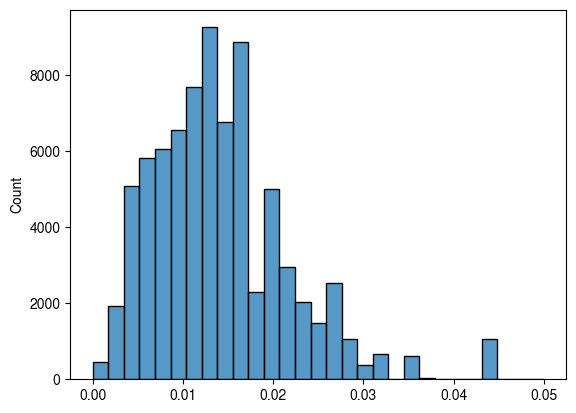

In [52]:
primaries = particles[particles.is_primary]
itk_d0 = np.sqrt(primaries.vx**2 + primaries.vy**2)
bins = np.linspace(0, 0.05, 30)
sns.histplot(itk_d0, bins=bins)

<Axes: xlabel='vz', ylabel='Count'>

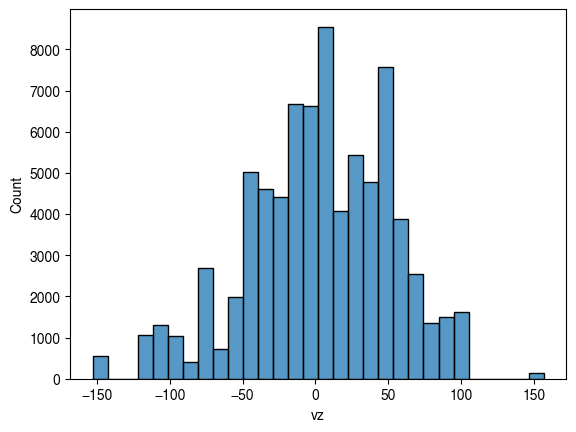

In [53]:
itk_z0 = primaries.vz
sns.histplot(itk_z0, bins=30)

Text(0.5, 1.0, 'Beamspot (d0, mm)')

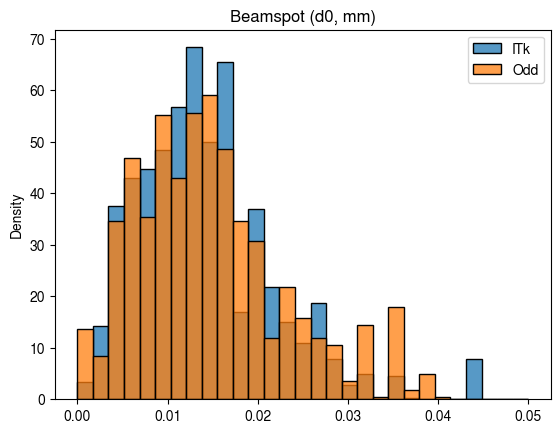

In [54]:
bins = np.linspace(0, 0.05, 30)
sns.histplot(itk_d0, bins=bins, stat="density")
sns.histplot(odd_d0, bins=bins, stat="density")

# Add legend
plt.legend(["ITk", "Odd"])

# Add title
plt.title("Beamspot (d0, mm)")

Text(0.5, 1.0, 'Beamspot (z0, mm)')

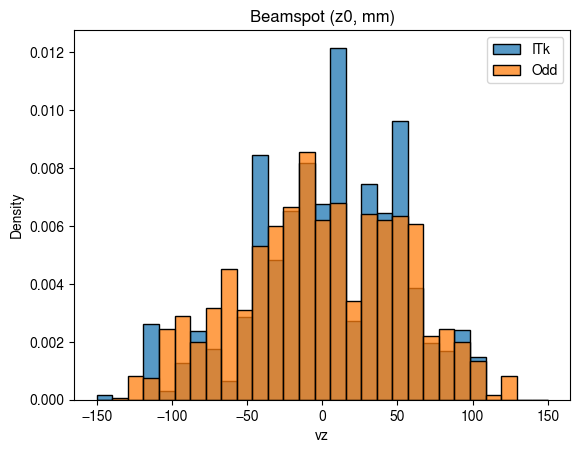

In [56]:
bins = np.linspace(-150, 150, 30)
sns.histplot(itk_z0, bins=bins, stat="density")
sns.histplot(odd_z0, bins=bins, stat="density")

# Add legend
plt.legend(["ITk", "Odd"])

# Add title
plt.title("Beamspot (z0, mm)")


## Event Viz

In [122]:
# Process the dataframes for useful features
x, y, z = hits_df["tx"], hits_df["ty"], hits_df["tz"]
r, theta = np.sqrt(x**2 + y**2), np.arctan2(y, x)
R = np.sqrt(x**2 + y**2 + z**2)
eta = -np.log(np.tan(theta/2))
phi = np.arctan2(z, r)
hits_df["r"] = r
hits_df["theta"] = theta
hits_df["eta"] = eta
hits_df["phi"] = phi
hits_df["R"] = R

px, py, pz = hits_df["tpx"], hits_df["tpy"], hits_df["tpz"]
pt = np.sqrt(px**2 + py**2)
hits_df["pt"] = pt

medium_pt_hits = hits_df[hits_df["pt"] > 0.6]
high_pt_hits = hits_df[hits_df["pt"] > 1]

/global/homes/d/danieltm/.conda/envs/acorn/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [123]:
hits_df

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,boundary_id,layer_id,approach_id,sensitive_id,r,theta,eta,phi,R,pt
entry,,,,,,,,,,,,,,,,,,,,,
0,0,1152921779484754177,5378812728850343,78.721382,-6.554311,-1515.599976,2605.782471,0.098129,-0.030286,-2.226882,...,0,4,0,1,78.993767,-0.083068,NaN,-1.518723,1517.657104,0.102696
1,0,1152921779484754177,5437087516309655,44.188232,-1.797172,-1515.538818,5608.444824,-0.000164,-0.000199,-0.000209,...,0,4,0,1,44.224762,-0.040648,NaN,-1.541624,1516.183960,0.000258
2,0,1152921779484754177,7345840843230855,60.325100,0.414169,-1515.599976,2607.291260,0.364005,0.019535,-8.919940,...,0,4,0,1,60.326523,0.006866,5.674389,-1.531014,1516.800049,0.364529
3,0,1152921779484754177,5077546408793866,74.866425,-5.316058,-1515.599976,2296.278320,0.339001,-0.043317,-6.912889,...,0,4,0,1,75.054924,-0.070888,NaN,-1.521315,1517.457275,0.341757
4,0,1152921779484754177,8604782629949128,75.994827,-1.064306,-1515.599976,2386.070068,0.590849,0.017778,-11.711026,...,0,4,0,1,76.002281,-0.014004,NaN,-1.520692,1517.504395,0.591116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208491,0,2161728645771608066,5058853771417503,445.599243,911.609497,3009.500000,4328.481934,-0.143399,0.393882,1.140655,...,0,12,0,192,1014.687439,1.116145,0.471176,1.245604,3175.953613,0.419173
208492,0,2161728645771608066,7760354445502333,418.279877,910.006775,3009.500000,155133.171875,0.001027,0.002121,-0.001399,...,0,12,0,192,1001.533997,1.139951,0.444829,1.249534,3171.775635,0.002357
208493,0,2161728645771608066,7760354445502333,420.043243,916.367004,3009.500000,155140.031250,-0.000087,0.000856,0.000868,...,0,12,0,192,1008.049988,1.140996,0.443678,1.247586,3173.839111,0.000861


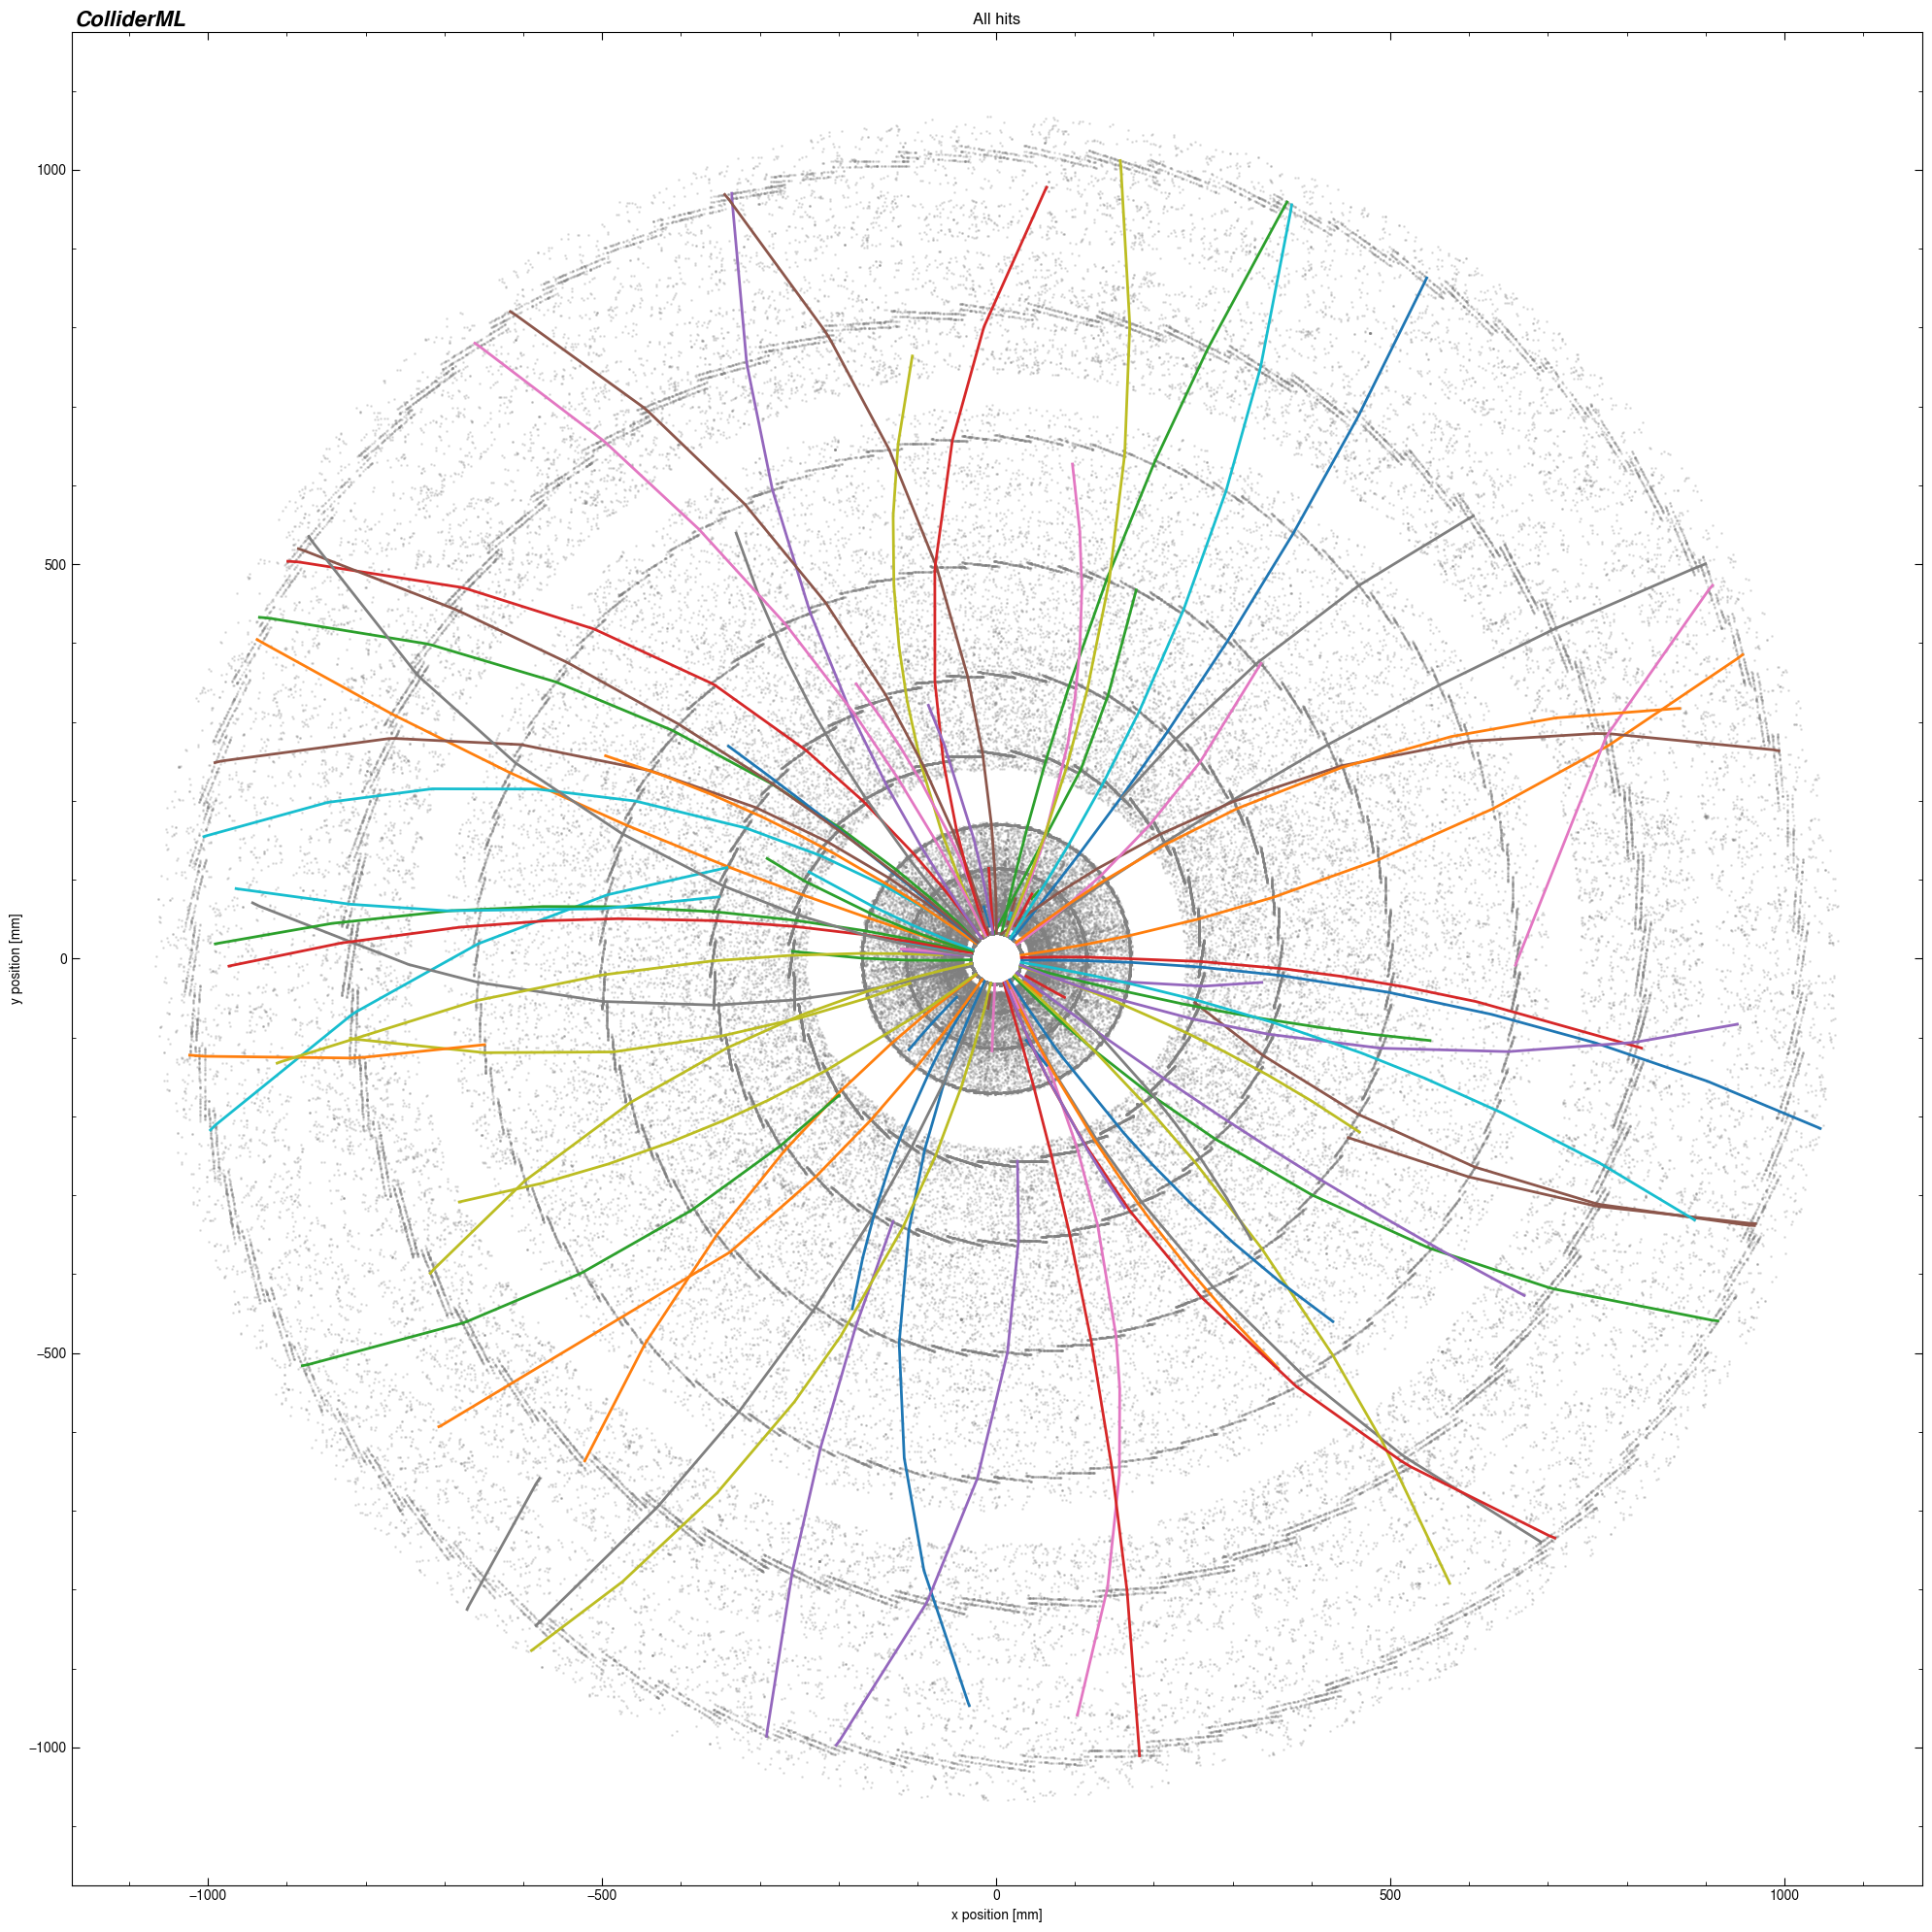

In [124]:
plt.figure(figsize=(20, 20))

# Create color map for calorimeter hits based on energy
# calo_colors = plt.cm.RdYlBu_r(calo_df["energy"]/calo_df["energy"].max())
# plt.scatter(calo_df["x"], calo_df["y"], 
#            s=1, 
#            alpha=np.sqrt(calo_df["energy"]/calo_df["energy"].max()), 
#            c=calo_df["energy"],
#            cmap='RdYlBu_r',  # Red (high) to Blue (low) colormap
#            norm=matplotlib.colors.LogNorm(
#                vmin=calo_df["energy"].quantile(0.4),  # 10th percentile
#                vmax=calo_df["energy"].quantile(0.95)   # 90th percentile
#            )
#            )

plt.scatter(hits_df["tx"], hits_df["ty"], s=1, alpha=0.2, color="gray")
plt.xlabel("x position [mm]")
plt.ylabel("y position [mm]")
plt.title("All hits")

# For a random set of N highpT particles, let's also connect the hits to the particles
N = 100
random_particles = np.random.choice(medium_pt_hits["particle_id"].unique(), N, replace=False)

for particle_id in random_particles:
    particle_hits = medium_pt_hits[medium_pt_hits["particle_id"] == particle_id]
    # sort the hits in increasing time
    particle_hits = particle_hits.sort_values(by="tt")
    plt.plot(particle_hits["tx"], particle_hits["ty"], label=f"Particle {particle_id}", linewidth=2)

atl.atlasify(outside=True)
# Don't show legend
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()